# Pipeline de Treinamento — Previsão de `geek_rating` (BoardGameGeek)

## 1. Imports

In [12]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import ParameterSampler, cross_val_score, train_test_split, StratifiedKFold, KFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, log_loss
)

import shap

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

N_OUTER = 5   # folds da validação cruzada externa (estimativa de generalização)
N_INNER = 3   # folds da validação cruzada interna (escolha de hiperparâmetros)
N_ITER = 20   # nº de combinações de hiperparâmetros amostradas (RandomizedSearchCV / ParameterSampler)

## 2. Carregamento dos dados

In [13]:
df = pd.read_csv("../data/bgg_dataset_tratado.csv")

print(f"Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"Valores nulos totais: {df.isna().sum().sum()}")
df.head()

Shape: 8,210 linhas x 159 colunas
Valores nulos totais: 0


,geek_rating,complexity,min_players,max_players,min_time,max_time,min_suggested_age,publisher_freq,min_time_was_missing,max_time_was_missing,min_suggested_age_was_missing,cat_Abstract Strategy,cat_Action,cat_Adventure,cat_Ancient,cat_Animals,cat_Bluffing,cat_Card Game,cat_Children's Game,cat_City Building,cat_Civilization,cat_Deduction,cat_Dexterity,cat_Dice,cat_Economic,...,desc_topic_28,desc_topic_29,desc_topic_30,desc_topic_31,desc_topic_32,desc_topic_33,desc_topic_34,desc_topic_35,desc_topic_36,desc_topic_37,desc_topic_38,desc_topic_39,desc_topic_40,desc_topic_41,desc_topic_42,desc_topic_43,desc_topic_44,desc_topic_45,desc_topic_46,desc_topic_47,desc_topic_48,desc_topic_49,desc_topic_50,desc_topic_51,desc_topic_52
0,8.394,3.86,2,4,60,120,14,0.001434,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,...,-0.058433,0.009345,0.016651,0.015986,0.025000,-0.030609,-0.081961,-0.016744,-0.009982,0.004833,-0.023359,-0.006700,0.052733,0.025746,0.019850,0.026079,0.043745,-0.015449,-0.025951,0.014756,-0.005542,0.034305,-0.014527,-0.028504,-0.014838
1,8.354,3.80,1,4,90,150,14,0.000717,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,...,-0.007228,-0.000323,-0.007158,-0.014286,-0.005762,-0.007796,-0.012167,0.005890,-0.002589,0.013608,-0.003286,0.005077,0.024767,0.003011,0.009170,-0.000891,0.028214,0.000953,-0.008084,-0.011957,-0.000410,0.005482,0.013064,0.002398,0.009475
2,8.345,2.83,2,4,60,60,13,0.003824,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.030072,0.105894,0.147805,0.062949,0.016788,-0.083384,-0.083061,-0.055188,-0.073196,-0.014462,0.041995,0.020503,0.101092,0.024867,0.029581,0.060664,0.013352,0.010287,0.040223,-0.192117,0.088284,-0.062375,-0.111520,0.004890,-0.002578
3,8.296,3.92,1,4,60,120,14,0.000598,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,...,-0.004115,0.032672,-0.024888,-0.011800,0.042112,-0.024433,0.000060,-0.021509,0.040342,0.009034,-0.046759,-0.015859,-0.075984,0.045251,0.013637,-0.143884,-0.033575,0.044223,0.049792,0.067953,0.152963,-0.082917,0.082087,-0.026368,0.016273
4,8.244,3.52,1,6,60,120,13,0.000478,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.002094,0.096413,0.017487,-0.033244,-0.074337,-0.002380,-0.047295,0.040982,-0.031296,-0.030977,0.010333,0.041498,0.029307,0.211799,0.005364,0.071105,-0.161384,-0.049646,0.021953,0.022739,-0.021775,-0.023202,0.085675,-0.043328,-0.076606


In [14]:
df["geek_rating"].describe()

count    8210.000000
mean        5.814454
std         0.480885
min         5.268000
25%         5.520000
50%         5.592000
75%         5.898000
max         8.394000
Name: geek_rating, dtype: float64

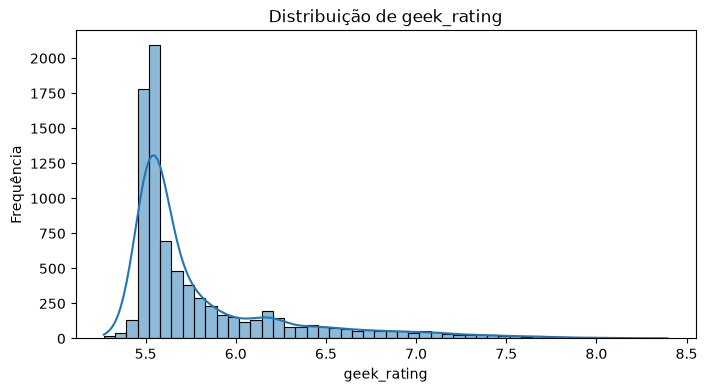

In [15]:
plt.figure(figsize=(8, 4))
sns.histplot(df["geek_rating"], bins=50, kde=True)
plt.title("Distribuição de geek_rating")
plt.xlabel("geek_rating")
plt.ylabel("Frequência")
plt.show()

## 3. Separação de features e target

In [16]:
X = df.drop(columns=["geek_rating"])
y_reg = df["geek_rating"]

print(f"X: {X.shape}")
print(f"y_reg: {y_reg.shape}")

X: (8210, 158)
y_reg: (8210,)


## 4. Holdout de teste final

In [17]:
X_train_full, X_test, y_train_full_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Treino+Validação (usado no Nested CV): {X_train_full.shape[0]:,} amostras")
print(f"Teste (holdout final):                  {X_test.shape[0]:,} amostras")

Treino+Validação (usado no Nested CV): 6,568 amostras
Teste (holdout final):                  1,642 amostras


## 5. Baseline

In [18]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train_full, y_train_full_reg)
y_pred_baseline = baseline.predict(X_test)

rmse_baseline = mean_squared_error(y_test_reg, y_pred_baseline) ** 0.5
mae_baseline = mean_absolute_error(y_test_reg, y_pred_baseline)
r2_baseline = r2_score(y_test_reg, y_pred_baseline)

resultado_baseline = {"modelo": "Baseline (média)", "RMSE": rmse_baseline, "MAE": mae_baseline, "R2": r2_baseline}

print("--- Baseline (prevê sempre a média do treino) ---")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"MAE:  {mae_baseline:.4f}")
print(f"R²:   {r2_baseline:.4f}  (por definição, R² do baseline-média é ~0 no próprio treino; no teste pode ser levemente negativo)")

--- Baseline (prevê sempre a média do treino) ---
RMSE: 0.4899
MAE:  0.3551
R²:   -0.0008  (por definição, R² do baseline-média é ~0 no próprio treino; no teste pode ser levemente negativo)


## 6. Função auxiliar de avaliação (regressão)

In [19]:
def avaliar_regressao(nome_modelo, modelo, X_eval, y_eval):
    y_pred = modelo.predict(X_eval)
    rmse = mean_squared_error(y_eval, y_pred) ** 0.5
    mae = mean_absolute_error(y_eval, y_pred)
    r2 = r2_score(y_eval, y_pred)

    print(f"--- {nome_modelo} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

    return {"modelo": nome_modelo, "RMSE": rmse, "MAE": mae, "R2": r2}

## 7. Nested Cross-Validation — função genérica

In [20]:
def nested_cv_regressao(nome_modelo, pipeline, param_distributions, X, y,
                          n_outer=N_OUTER, n_inner=N_INNER, n_iter=N_ITER,
                          random_state=RANDOM_STATE):
    """Executa Nested Cross-Validation para um pipeline de regressão.

    Retorna um dicionário com as métricas agregadas (média e desvio padrão
    dos folds externos) e a lista de melhores hiperparâmetros encontrados
    em cada fold externo (útil para inspecionar estabilidade da busca).
    """
    outer_cv = KFold(n_splits=n_outer, shuffle=True, random_state=random_state)

    r2_scores, rmse_scores, mae_scores = [], [], []
    melhores_params_por_fold = []

    t0 = time.time()
    for fold_i, (train_idx, val_idx) in enumerate(outer_cv.split(X), start=1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        inner_cv = KFold(n_splits=n_inner, shuffle=True, random_state=random_state)

        busca = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_distributions,
            n_iter=n_iter,
            cv=inner_cv,
            scoring="r2",
            random_state=random_state,
            n_jobs=-1,
        )
        busca.fit(X_tr, y_tr)

        melhor_modelo = busca.best_estimator_
        y_pred_val = melhor_modelo.predict(X_val)

        r2_fold = r2_score(y_val, y_pred_val)
        rmse_fold = mean_squared_error(y_val, y_pred_val) ** 0.5
        mae_fold = mean_absolute_error(y_val, y_pred_val)

        r2_scores.append(r2_fold)
        rmse_scores.append(rmse_fold)
        mae_scores.append(mae_fold)
        melhores_params_por_fold.append(busca.best_params_)

        print(f"  [{nome_modelo}] Fold externo {fold_i}/{n_outer} — "
              f"R²={r2_fold:.4f}  RMSE={rmse_fold:.4f}  MAE={mae_fold:.4f}  "
              f"melhores_params={busca.best_params_}")

    tempo_total = time.time() - t0
    print(f"  [{nome_modelo}] Nested CV concluído em {tempo_total:.1f}s")

    resultado = {
        "modelo": nome_modelo,
        "R2_mean": np.mean(r2_scores),
        "R2_std": np.std(r2_scores),
        "RMSE_mean": np.mean(rmse_scores),
        "RMSE_std": np.std(rmse_scores),
        "MAE_mean": np.mean(mae_scores),
        "MAE_std": np.std(mae_scores),
        "r2_scores_por_fold": r2_scores,
        "rmse_scores_por_fold": rmse_scores,
        "mae_scores_por_fold": mae_scores,
        "melhores_params_por_fold": melhores_params_por_fold,
        "tempo_segundos": tempo_total,
    }
    return resultado

## 8. Modelo 1 — Regressão Linear

In [21]:
pipeline_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

param_dist_linear = {
    "model__fit_intercept": [True, False],
    "model__positive": [True, False],
}

resultado_nested_linear = nested_cv_regressao(
    "Regressão Linear", pipeline_linear, param_dist_linear, X_train_full, y_train_full_reg
)

print()
print(f"R² (Nested CV): {resultado_nested_linear['R2_mean']:.4f} ± {resultado_nested_linear['R2_std']:.4f}")

c:\Users\Gabriel\vscode_projects\trabalho_machine_learning\venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  [Regressão Linear] Fold externo 1/5 — R²=0.3598  RMSE=0.3688  MAE=0.2587  melhores_params={'model__positive': False, 'model__fit_intercept': True}


c:\Users\Gabriel\vscode_projects\trabalho_machine_learning\venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  [Regressão Linear] Fold externo 2/5 — R²=0.3602  RMSE=0.4047  MAE=0.2845  melhores_params={'model__positive': False, 'model__fit_intercept': True}


c:\Users\Gabriel\vscode_projects\trabalho_machine_learning\venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  [Regressão Linear] Fold externo 3/5 — R²=0.3419  RMSE=0.3995  MAE=0.2774  melhores_params={'model__positive': False, 'model__fit_intercept': True}


c:\Users\Gabriel\vscode_projects\trabalho_machine_learning\venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  [Regressão Linear] Fold externo 4/5 — R²=0.3088  RMSE=0.3771  MAE=0.2595  melhores_params={'model__positive': True, 'model__fit_intercept': True}


c:\Users\Gabriel\vscode_projects\trabalho_machine_learning\venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  [Regressão Linear] Fold externo 5/5 — R²=0.3017  RMSE=0.3982  MAE=0.2742  melhores_params={'model__positive': True, 'model__fit_intercept': True}
  [Regressão Linear] Nested CV concluído em 10.0s

R² (Nested CV): 0.3345 ± 0.0249


## 9. Modelo 2 — Random Forest Regressor

In [22]:
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1))
])

param_dist_rf = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [6, 8, 12, None],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", 0.5, None],
}

resultado_nested_rf = nested_cv_regressao(
    "Random Forest", pipeline_rf, param_dist_rf, X_train_full, y_train_full_reg
)

print()
print(f"R² (Nested CV): {resultado_nested_rf['R2_mean']:.4f} ± {resultado_nested_rf['R2_std']:.4f}")

  [Random Forest] Fold externo 1/5 — R²=0.3966  RMSE=0.3581  MAE=0.2408  melhores_params={'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
  [Random Forest] Fold externo 2/5 — R²=0.3879  RMSE=0.3958  MAE=0.2668  melhores_params={'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
  [Random Forest] Fold externo 3/5 — R²=0.3799  RMSE=0.3878  MAE=0.2606  melhores_params={'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
  [Random Forest] Fold externo 4/5 — R²=0.3991  RMSE=0.3516  MAE=0.2354  melhores_params={'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
  [Random Forest] Fold externo 5/5 — R²=0.3716  RMSE=0.3777  MAE=0.2477  melhores_params={'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_dept

## 10. Modelo 3 — Gradient Boosting Regressor

In [23]:
pipeline_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

param_dist_gb = {
    "model__n_estimators": [100, 150, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.8, 1.0],
}

resultado_nested_gb = nested_cv_regressao(
    "Gradient Boosting", pipeline_gb, param_dist_gb, X_train_full, y_train_full_reg
)

print()
print(f"R² (Nested CV): {resultado_nested_gb['R2_mean']:.4f} ± {resultado_nested_gb['R2_std']:.4f}")

  [Gradient Boosting] Fold externo 1/5 — R²=0.4350  RMSE=0.3465  MAE=0.2335  melhores_params={'model__subsample': 1.0, 'model__n_estimators': 150, 'model__max_depth': 4, 'model__learning_rate': 0.05}
  [Gradient Boosting] Fold externo 2/5 — R²=0.4245  RMSE=0.3838  MAE=0.2562  melhores_params={'model__subsample': 0.8, 'model__n_estimators': 150, 'model__max_depth': 3, 'model__learning_rate': 0.1}
  [Gradient Boosting] Fold externo 3/5 — R²=0.4142  RMSE=0.3769  MAE=0.2501  melhores_params={'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.05}
  [Gradient Boosting] Fold externo 4/5 — R²=0.3925  RMSE=0.3535  MAE=0.2340  melhores_params={'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.1}
  [Gradient Boosting] Fold externo 5/5 — R²=0.3989  RMSE=0.3694  MAE=0.2427  melhores_params={'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.05}
  

## 11. Modelos finais — refit completo e avaliação no holdout de teste

In [24]:
def treinar_modelo_final(nome_modelo, pipeline, param_distributions, X_tr_full, y_tr_full, X_te, y_te,
                           n_inner=N_INNER, n_iter=N_ITER, random_state=RANDOM_STATE):
    inner_cv = KFold(n_splits=n_inner, shuffle=True, random_state=random_state)
    busca_final = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        cv=inner_cv,
        scoring="r2",
        random_state=random_state,
        n_jobs=-1,
    )
    busca_final.fit(X_tr_full, y_tr_full)

    modelo_final = busca_final.best_estimator_
    resultado_holdout = avaliar_regressao(nome_modelo, modelo_final, X_te, y_te)

    print(f"Melhores hiperparâmetros (refit final): {busca_final.best_params_}")
    return modelo_final, resultado_holdout, busca_final.best_params_

In [25]:
modelo_linear, resultado_linear, params_linear = treinar_modelo_final(
    "Regressão Linear", pipeline_linear, param_dist_linear, X_train_full, y_train_full_reg, X_test, y_test_reg
)

c:\Users\Gabriel\vscode_projects\trabalho_machine_learning\venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


--- Regressão Linear ---
RMSE: 0.3894
MAE:  0.2757
R²:   0.3679
Melhores hiperparâmetros (refit final): {'model__positive': False, 'model__fit_intercept': True}


In [26]:
modelo_rf, resultado_rf, params_rf = treinar_modelo_final(
    "Random Forest", pipeline_rf, param_dist_rf, X_train_full, y_train_full_reg, X_test, y_test_reg
)

--- Random Forest ---
RMSE: 0.3813
MAE:  0.2600
R²:   0.3938
Melhores hiperparâmetros (refit final): {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}


In [27]:
modelo_gb, resultado_gb, params_gb = treinar_modelo_final(
    "Gradient Boosting", pipeline_gb, param_dist_gb, X_train_full, y_train_full_reg, X_test, y_test_reg
)

--- Gradient Boosting ---
RMSE: 0.3787
MAE:  0.2594
R²:   0.4020
Melhores hiperparâmetros (refit final): {'model__subsample': 0.8, 'model__n_estimators': 150, 'model__max_depth': 3, 'model__learning_rate': 0.1}


## 12. Comparação dos modelos — baseline, Nested CV e holdout final

In [28]:
tabela_nested = pd.DataFrame([
    {"modelo": r["modelo"], "R2_mean_nestedCV": r["R2_mean"], "R2_std_nestedCV": r["R2_std"],
     "RMSE_mean_nestedCV": r["RMSE_mean"], "MAE_mean_nestedCV": r["MAE_mean"]}
    for r in [resultado_nested_linear, resultado_nested_rf, resultado_nested_gb]
]).set_index("modelo")

tabela_holdout = pd.DataFrame([resultado_baseline, resultado_linear, resultado_rf, resultado_gb]).set_index("modelo")
tabela_holdout = tabela_holdout.rename(columns={"R2": "R2_holdout", "RMSE": "RMSE_holdout", "MAE": "MAE_holdout"})

tabela_comparativa = tabela_holdout.join(tabela_nested, how="left")
tabela_comparativa = tabela_comparativa.sort_values("R2_holdout", ascending=False)
print("Comparação completa — Baseline, Nested CV (treino+validação) e Holdout (teste final)")
tabela_comparativa

Comparação completa — Baseline, Nested CV (treino+validação) e Holdout (teste final)


,RMSE_holdout,MAE_holdout,R2_holdout,R2_mean_nestedCV,R2_std_nestedCV,RMSE_mean_nestedCV,MAE_mean_nestedCV
modelo,,,,,,,
Gradient Boosting,0.378736,0.259354,0.401971,0.413025,0.015732,0.366015,0.243290
Random Forest,0.381304,0.260030,0.393835,0.387018,0.010239,0.374186,0.250271
Regressão Linear,0.389382,0.275709,0.367878,0.334477,0.024862,0.389639,0.270867
Baseline (média),0.489938,0.355088,-0.000763,NaN,NaN,NaN,NaN


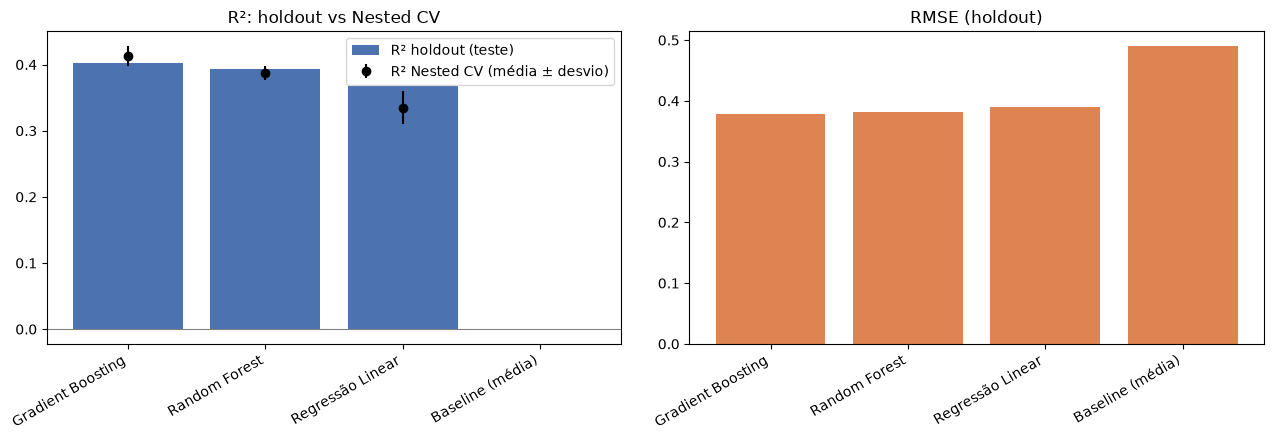

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

modelos_plot = tabela_comparativa.index
x_pos = np.arange(len(modelos_plot))

axes[0].bar(x_pos, tabela_comparativa["R2_holdout"], color="#4C72B0", label="R² holdout (teste)")
axes[0].errorbar(x_pos, tabela_comparativa["R2_mean_nestedCV"],
                  yerr=tabela_comparativa["R2_std_nestedCV"],
                  fmt="o", color="black", label="R² Nested CV (média ± desvio)")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(modelos_plot, rotation=30, ha="right")
axes[0].set_title("R²: holdout vs Nested CV")
axes[0].axhline(0, color="grey", linewidth=0.8)
axes[0].legend()

axes[1].bar(x_pos, tabela_comparativa["RMSE_holdout"], color="#DD8452")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(modelos_plot, rotation=30, ha="right")
axes[1].set_title("RMSE (holdout)")

plt.tight_layout()
plt.show()

## 13. Análise de resíduos

In [30]:
def plot_residuos(nome_modelo, modelo, X_eval, y_eval, ax_resid, ax_hist):
    y_pred = modelo.predict(X_eval)
    residuos = y_eval.values - y_pred

    ax_resid.scatter(y_pred, residuos, alpha=0.35, s=12, color="#4C72B0")
    ax_resid.axhline(0, color="red", linestyle="--", linewidth=1)
    ax_resid.set_xlabel("Valor predito")
    ax_resid.set_ylabel("Resíduo (real - predito)")
    ax_resid.set_title(f"Resíduos × Predição — {nome_modelo}")

    sns.histplot(residuos, bins=40, kde=True, ax=ax_hist, color="#55A868")
    ax_hist.axvline(0, color="red", linestyle="--", linewidth=1)
    ax_hist.set_xlabel("Resíduo")
    ax_hist.set_title(f"Distribuição dos resíduos — {nome_modelo}")

    return residuos

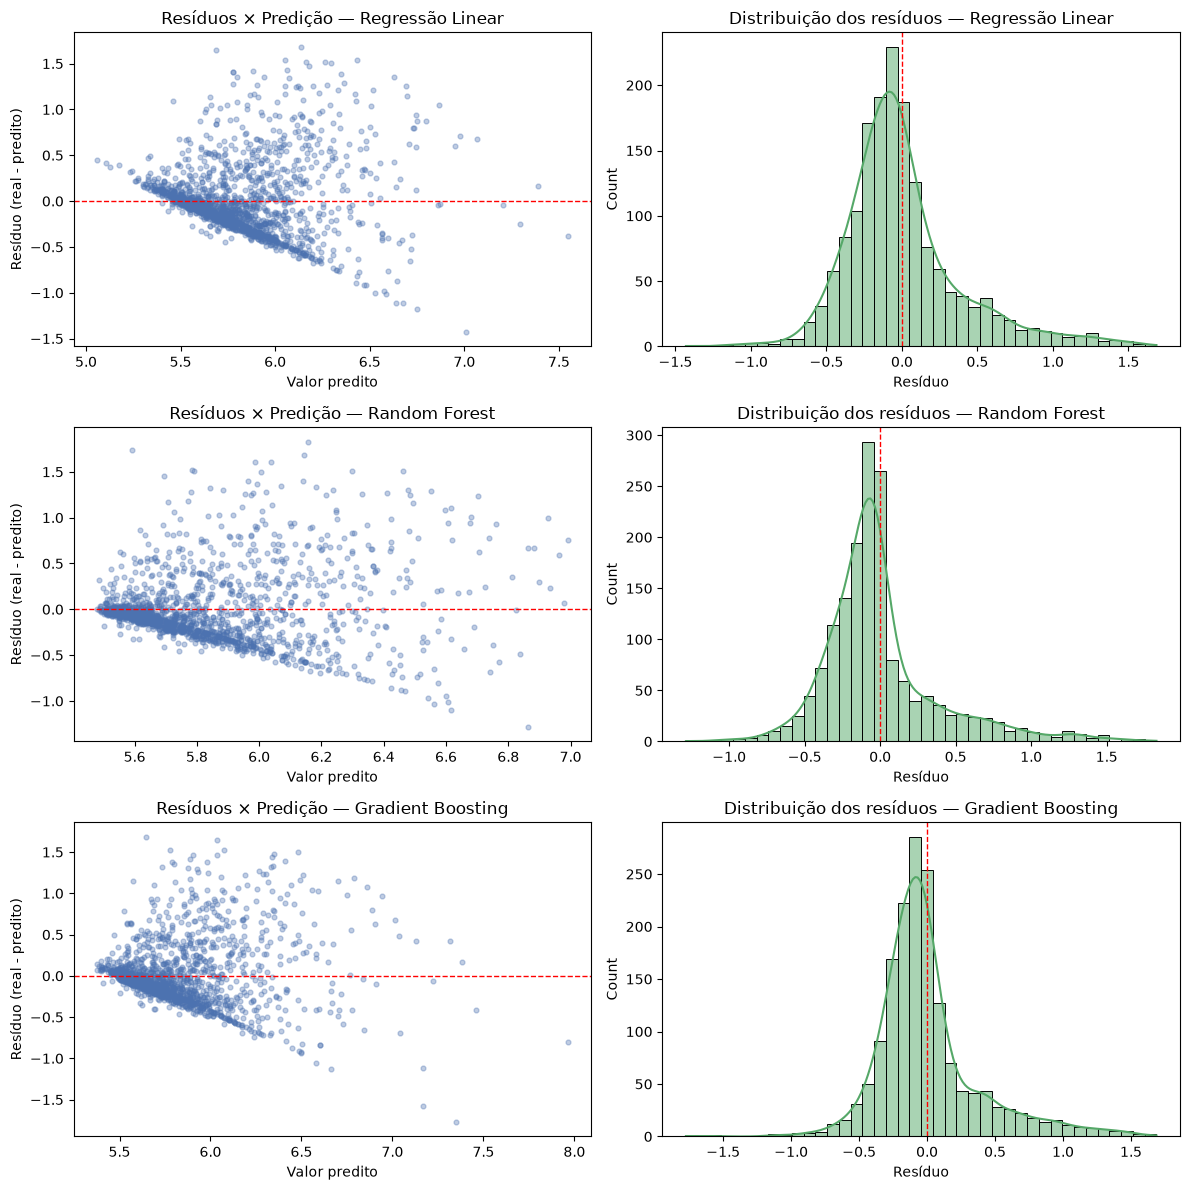

In [31]:
modelos_finais = [
    ("Regressão Linear", modelo_linear),
    ("Random Forest", modelo_rf),
    ("Gradient Boosting", modelo_gb),
]

fig, axes = plt.subplots(len(modelos_finais), 2, figsize=(12, 4 * len(modelos_finais)))

residuos_por_modelo = {}
for i, (nome, modelo) in enumerate(modelos_finais):
    residuos = plot_residuos(nome, modelo, X_test, y_test_reg, axes[i, 0], axes[i, 1])
    residuos_por_modelo[nome] = residuos

plt.tight_layout()
plt.show()

## 14. Feature importance — Permutation Importance e SHAP

### 14.1 Permutation Importance (Random Forest e Gradient Boosting)

In [32]:
def calcular_permutation_importance(nome_modelo, modelo, X_eval, y_eval, n_repeats=10):
    resultado_perm = permutation_importance(
        modelo, X_eval, y_eval,
        scoring="r2", n_repeats=n_repeats, random_state=RANDOM_STATE, n_jobs=-1
    )
    importancias = pd.Series(resultado_perm.importances_mean, index=X_eval.columns)
    desvios = pd.Series(resultado_perm.importances_std, index=X_eval.columns)
    return importancias, desvios

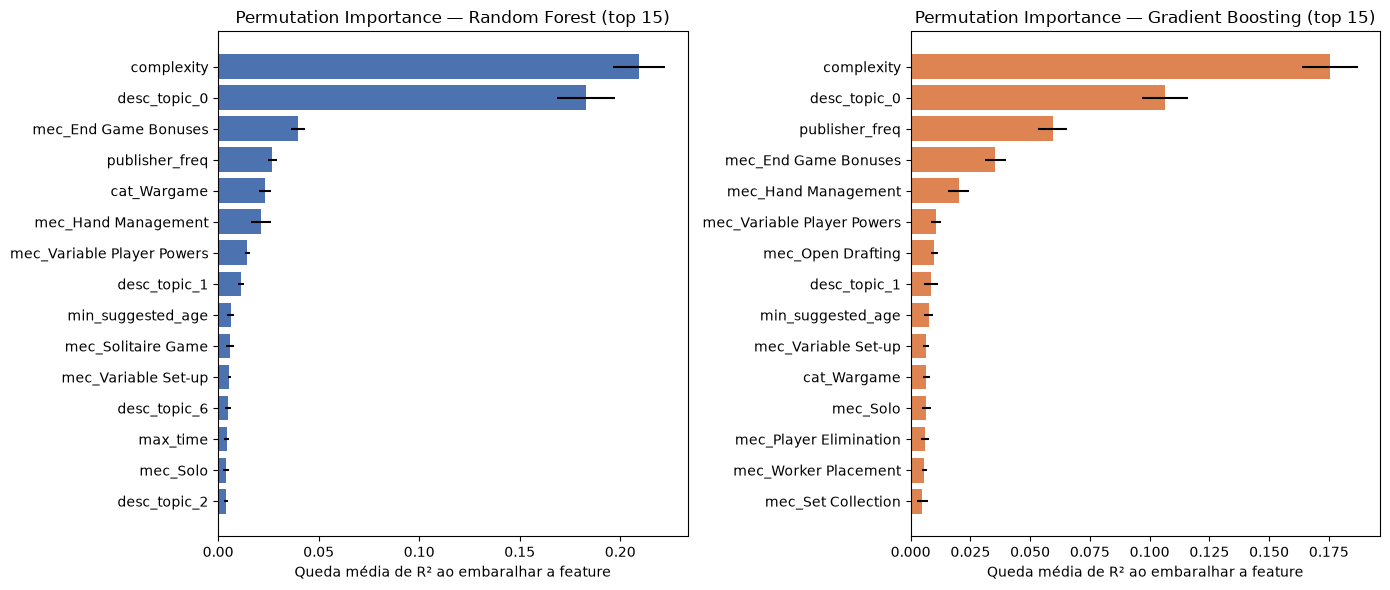

In [33]:
perm_imp_rf, perm_std_rf = calcular_permutation_importance("Random Forest", modelo_rf, X_test, y_test_reg)
perm_imp_gb, perm_std_gb = calcular_permutation_importance("Gradient Boosting", modelo_gb, X_test, y_test_reg)

top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_rf = perm_imp_rf.sort_values(ascending=False).head(top_n)
axes[0].barh(top_rf.index[::-1], top_rf.values[::-1],
             xerr=perm_std_rf.loc[top_rf.index][::-1], color="#4C72B0")
axes[0].set_title(f"Permutation Importance — Random Forest (top {top_n})")
axes[0].set_xlabel("Queda média de R² ao embaralhar a feature")

top_gb = perm_imp_gb.sort_values(ascending=False).head(top_n)
axes[1].barh(top_gb.index[::-1], top_gb.values[::-1],
             xerr=perm_std_gb.loc[top_gb.index][::-1], color="#DD8452")
axes[1].set_title(f"Permutation Importance — Gradient Boosting (top {top_n})")
axes[1].set_xlabel("Queda média de R² ao embaralhar a feature")

plt.tight_layout()
plt.show()

### 14.2 SHAP (Random Forest e Gradient Boosting)

In [34]:
N_AMOSTRA_SHAP = 500
amostra_shap = X_test.sample(n=min(N_AMOSTRA_SHAP, len(X_test)), random_state=RANDOM_STATE)

def calcular_shap_values(pipeline, amostra):
    scaler = pipeline.named_steps["scaler"]
    modelo_arvore = pipeline.named_steps["model"]
    amostra_escalada = pd.DataFrame(
        scaler.transform(amostra), columns=amostra.columns, index=amostra.index
    )
    explainer = shap.TreeExplainer(modelo_arvore)
    shap_values = explainer.shap_values(amostra_escalada)
    return shap_values, amostra_escalada

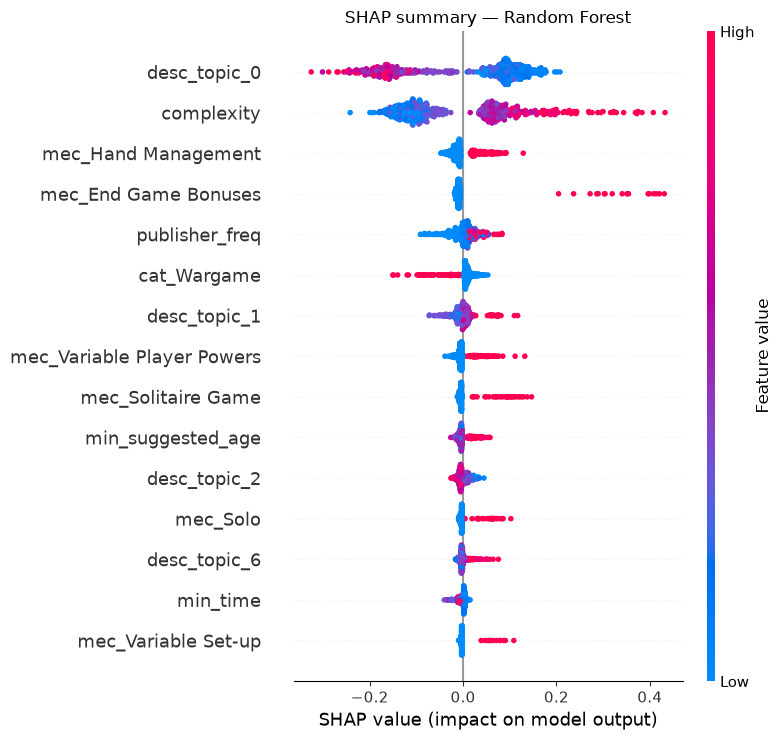

In [35]:
shap_values_rf, amostra_escalada_rf = calcular_shap_values(modelo_rf, amostra_shap)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values_rf, amostra_escalada_rf, max_display=15, show=False)
plt.title("SHAP summary — Random Forest")
plt.tight_layout()
plt.show()

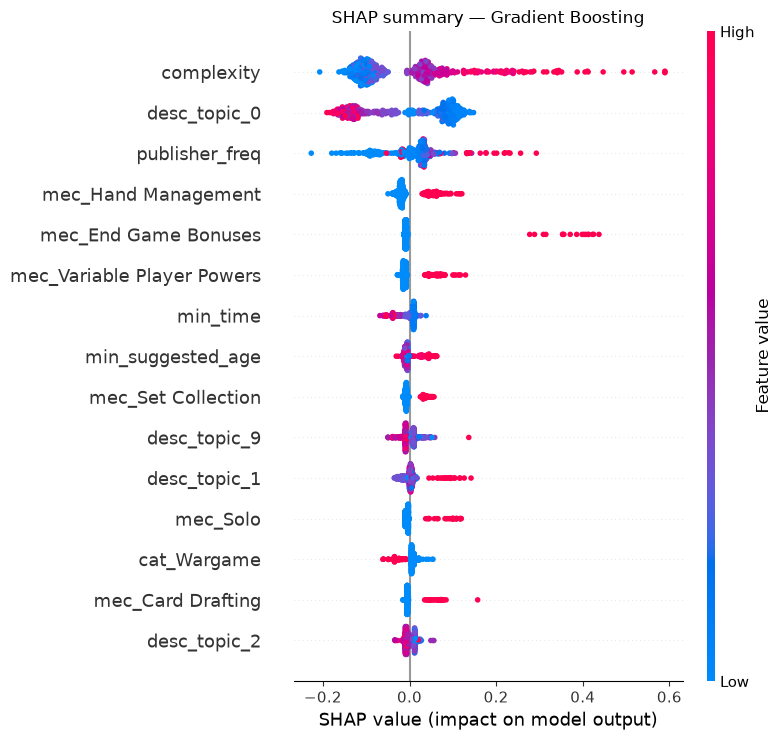

In [36]:
shap_values_gb, amostra_escalada_gb = calcular_shap_values(modelo_gb, amostra_shap)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values_gb, amostra_escalada_gb, max_display=15, show=False)
plt.title("SHAP summary — Gradient Boosting")
plt.tight_layout()
plt.show()

### 14.3 Comparação Random Forest vs Gradient Boosting (Permutation Importance) e coeficientes da Regressão Linear

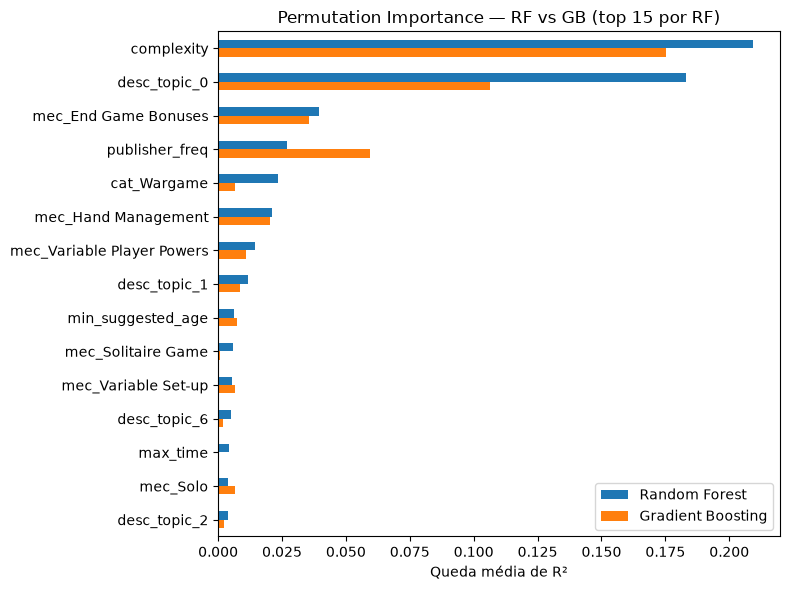

In [37]:
comparacao_perm = pd.DataFrame({
    "Random Forest": perm_imp_rf,
    "Gradient Boosting": perm_imp_gb,
}).sort_values("Random Forest", ascending=False).head(15)

comparacao_perm.plot(kind="barh", figsize=(8, 6))
plt.title("Permutation Importance — RF vs GB (top 15 por RF)")
plt.xlabel("Queda média de R²")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

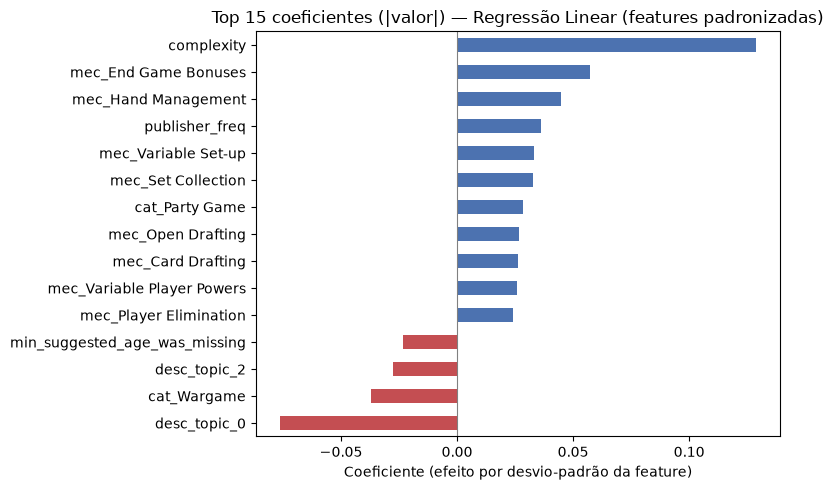

In [38]:
coef_linear = pd.Series(
    modelo_linear.named_steps["model"].coef_, index=X_train_full.columns
)
top_coef = coef_linear.reindex(coef_linear.abs().sort_values(ascending=False).head(15).index)

plt.figure(figsize=(8, 5))
top_coef.sort_values().plot(kind="barh", color=top_coef.sort_values().apply(lambda v: "#C44E52" if v < 0 else "#4C72B0"))
plt.title("Top 15 coeficientes (|valor|) — Regressão Linear (features padronizadas)")
plt.xlabel("Coeficiente (efeito por desvio-padrão da feature)")
plt.axvline(0, color="grey", linewidth=0.8)
plt.tight_layout()
plt.show()

## 15. Modelo 4 — Regressão Logística

### 15.1 Discretização do target

Faixas criadas (geek_rating):
  Classe 0 (nota 5): 5.0 até 6.0
  Classe 1 (nota 6): 6.0 até 7.0
  Classe 2 (nota 7): 7.0 até 8.0
  Classe 3 (nota 8): 8.0 até 8.5

Distribuição de classes no dataset completo:
geek_rating
0    6426
1    1422
2     345
3      17
Name: count, dtype: int64

Distribuição das amostras por classe (após split estratificado):
             treino_completo  teste_holdout
geek_rating                                
0                       5141           1285
1                       1138            284
2                        276             69
3                         13              4



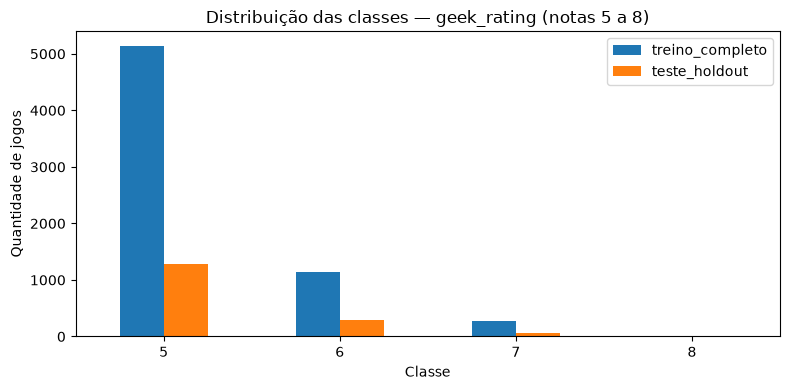

In [39]:
bin_edges = [5.0, 6.0, 7.0, 8.0, 8.5]

bin_edges_adjusted = bin_edges.copy()
bin_edges_adjusted[0] = -np.inf
bin_edges_adjusted[-1] = np.inf

CLASS_NAMES = ["5", "6", "7", "8"]

# Discretiza o target completo (antes de qualquer split) para podermos
# estratificar o holdout de teste por classe. Isso garante que classes
# raras (ex.: nota "8") apareçam tanto no treino quanto no teste.
y_clf = pd.cut(
    y_reg,
    bins=bin_edges_adjusted,
    labels=False,
    include_lowest=True
)

print("Faixas criadas (geek_rating):")
for i in range(len(bin_edges) - 1):
    print(f"  Classe {i} (nota {CLASS_NAMES[i]}): {bin_edges[i]} até {bin_edges[i+1]}")

print("\nDistribuição de classes no dataset completo:")
print(y_clf.value_counts().sort_index())

# Split próprio para a Regressão Logística, estratificado pelas classes.
# Usamos nomes com sufixo "_lr" para não confundir com X_train_full / X_test
# (split de regressão, usado pelos demais modelos da seção 7/8).
X_train_full_lr, X_test_lr, y_train_full_clf, y_test_clf = train_test_split(
    X, y_clf,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

dist_treino = y_train_full_clf.value_counts().sort_index()
dist_teste  = y_test_clf.value_counts().sort_index()

dist_df = pd.DataFrame({
    "treino_completo": dist_treino,
    "teste_holdout":   dist_teste,
}).fillna(0).astype(int)

print("\nDistribuição das amostras por classe (após split estratificado):")
print(dist_df)
print()

ax = dist_df.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Distribuição das classes — geek_rating (notas 5 a 8)")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade de jogos")
ax.set_xticklabels(CLASS_NAMES)
plt.tight_layout()
plt.show()

In [40]:
model_clf = LogisticRegression(
    solver='saga',
    class_weight='balanced',
    max_iter=2000,
    random_state=RANDOM_STATE
)

model_clf.fit(X_train_full_lr, y_train_full_clf)

y_test_pred = model_clf.predict(X_test_lr)

print("\n=== RESULTADOS NO HOLDOUT DE TESTE ===")
print(f"Acurácia: {accuracy_score(y_test_clf, y_test_pred):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test_clf, y_test_pred, target_names=CLASS_NAMES))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test_clf, y_test_pred))


=== RESULTADOS NO HOLDOUT DE TESTE ===
Acurácia: 0.0024

Relatório de Classificação:
              precision    recall  f1-score   support

           5       0.00      0.00      0.00      1285
           6       0.00      0.00      0.00       284
           7       0.00      0.00      0.00        69
           8       0.00      1.00      0.00         4

    accuracy                           0.00      1642
   macro avg       0.00      0.25      0.00      1642
weighted avg       0.00      0.00      0.00      1642


Matriz de Confusão:
[[   0    0    3 1282]
 [   0    0    0  284]
 [   0    0    0   69]
 [   0    0    0    4]]


c:\Users\Gabriel\vscode_projects\trabalho_machine_learning\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Gabriel\vscode_projects\trabalho_machine_learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Gabriel\vscode_projects\trabalho_machine_learning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Gabriel\vscode_projects\trabalho_machine_learnin

Distribuição das amostras por classe:
             Treino  Teste
geek_rating               
0              5141   1285
1              1138    284
2               276     69
3                13      4



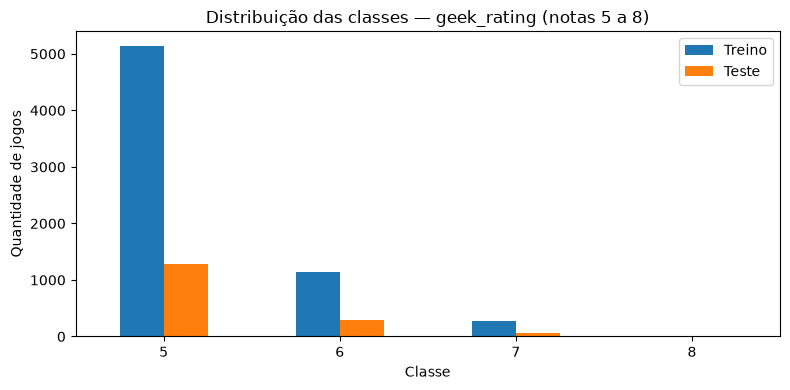

In [41]:
dist_treino = y_train_full_clf.value_counts().sort_index()
dist_teste  = y_test_clf.value_counts().sort_index()

dist_df = pd.DataFrame({
    "Treino": dist_treino,
    "Teste":  dist_teste,
}).fillna(0).astype(int)

print("Distribuição das amostras por classe:")
print(dist_df)
print()

ax = dist_df.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Distribuição das classes — geek_rating (notas 5 a 8)")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade de jogos")
ax.set_xticklabels(CLASS_NAMES)
plt.tight_layout()
plt.show()

### 15.2 Treinamento

In [42]:
from scipy.stats import loguniform


param_dist_log = {
    "model__C":       loguniform(1e-3, 1e2),
    "model__penalty": [None, "l2", "l1"],
}

best_score  = -np.inf
best_params = None
best_model  = None
candidatos_log = []


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

print("Iniciando a busca de hiperparâmetros com Validação Cruzada...")

for params in ParameterSampler(
    param_dist_log,
    n_iter=20,
    random_state=RANDOM_STATE
):
    if params["model__penalty"] is None:
        params["model__C"] = 1.0

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=5000,
            solver="saga",
            class_weight="balanced"
        ))
    ])

    model.set_params(**params)
    
    scores = cross_val_score(
        model, 
        X_train_full_lr, 
        y_train_full_clf, 
        cv=cv, 
        scoring="f1_weighted", 
        n_jobs=-1 
    )
    mean_score = np.mean(scores)

    candidatos_log.append({"params": params, "score_cv": mean_score})

    # Guarda a melhor combinação
    if mean_score > best_score:
        best_score  = mean_score
        best_params = params

print("\n=== BUSCA CONCLUÍDA ===")
print(f"Melhor F1-weighted médio (CV): {best_score:.4f}")
print(f"Melhores parâmetros encontrados: {best_params}")


print("\nTreinando o modelo final com os melhores parâmetros...")
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=5000,
        solver="saga",
        class_weight="balanced"
    ))
])
best_model.set_params(**best_params)
best_model.fit(X_train_full_lr, y_train_full_clf)
print("Modelo final guardado na variável 'best_model'!")

Iniciando a busca de hiperparâmetros com Validação Cruzada...

=== BUSCA CONCLUÍDA ===
Melhor F1-weighted médio (CV): 0.7184
Melhores parâmetros encontrados: {'model__C': np.float64(0.001267425589893723), 'model__penalty': 'l2'}

Treinando o modelo final com os melhores parâmetros...


c:\Users\Gabriel\vscode_projects\trabalho_machine_learning\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Modelo final guardado na variável 'best_model'!


c:\Users\Gabriel\vscode_projects\trabalho_machine_learning\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [43]:
modelo_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=5000,
        solver="saga",
        class_weight="balanced",
    ))
])

modelo_logistic.set_params(**best_params)

modelo_logistic.fit(X_train_full_lr, y_train_full_clf)

print("Modelo final (modelo_logistic) treinado com treino + validação com sucesso!")

c:\Users\Gabriel\vscode_projects\trabalho_machine_learning\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Modelo final (modelo_logistic) treinado com treino + validação com sucesso!


c:\Users\Gabriel\vscode_projects\trabalho_machine_learning\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [44]:
y_pred_clf = modelo_logistic.predict(X_test_lr)

acc                = accuracy_score(y_test_clf, y_pred_clf)
f1_weighted        = f1_score(y_test_clf,        y_pred_clf, average="weighted")
precision_weighted = precision_score(y_test_clf, y_pred_clf, average="weighted", zero_division=0)
recall_weighted    = recall_score(y_test_clf,    y_pred_clf, average="weighted", zero_division=0)

print("--- Regressão Logística (4 classes — notas 5, 6, 7, 8) ---")
print(f"Accuracy:              {acc:.4f}")
print(f"F1 (weighted):         {f1_weighted:.4f}")
print(f"Precision (weighted):  {precision_weighted:.4f}")
print(f"Recall (weighted):     {recall_weighted:.4f}")
print()
print(classification_report(
    y_test_clf,
    y_pred_clf,
    target_names=CLASS_NAMES,
    zero_division=0
))

--- Regressão Logística (4 classes — notas 5, 6, 7, 8) ---
Accuracy:              0.6882
F1 (weighted):         0.7268
Precision (weighted):  0.7894
Recall (weighted):     0.6882

              precision    recall  f1-score   support

           5       0.92      0.75      0.83      1285
           6       0.35      0.45      0.39       284
           7       0.17      0.52      0.26        69
           8       0.06      0.25      0.10         4

    accuracy                           0.69      1642
   macro avg       0.38      0.49      0.39      1642
weighted avg       0.79      0.69      0.73      1642



In [45]:
y_prob = modelo_logistic.predict_proba(X_test_lr)

In [46]:
roc_auc_weighted = roc_auc_score(
    y_test_clf,
    y_prob,
    multi_class="ovr",
    average="weighted",
    labels=modelo_logistic.classes_
)
print(f"ROC-AUC (OvR, weighted): {roc_auc_weighted:.4f}")

ROC-AUC (OvR, weighted): 0.8143


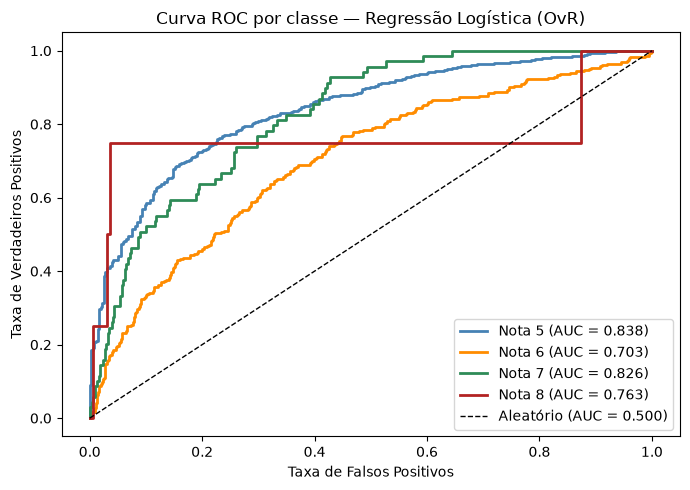

In [47]:
y_test_bin = label_binarize(y_test_clf, classes=range(len(CLASS_NAMES)))

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["steelblue", "darkorange", "seagreen", "firebrick"]

for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    if y_test_bin[:, i].sum() == 0:
        print(f"Aviso: classe '{name}' não aparece em y_test — pulando curva ROC dessa classe.")
        continue
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"Nota {name} (AUC = {auc_i:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatório (AUC = 0.500)")
ax.set_xlabel("Taxa de Falsos Positivos")
ax.set_ylabel("Taxa de Verdadeiros Positivos")
ax.set_title("Curva ROC por classe — Regressão Logística (OvR)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [48]:
n_classes = len(CLASS_NAMES)
loss = log_loss(y_test_clf, y_prob)

print(f"Log-Loss (Cross-Entropy): {loss:.4f}")
print()
print("Referência:")
print(f"  Classificador aleatório ({n_classes} classes): {-np.log(1/n_classes):.4f}")
print(f"  Seu modelo:                           {loss:.4f}  ",
      "✓ melhor que aleatório" if loss < -np.log(1/n_classes) else "✗ pior que aleatório")

Log-Loss (Cross-Entropy): 0.8049

Referência:
  Classificador aleatório (4 classes): 1.3863
  Seu modelo:                           0.8049   ✓ melhor que aleatório


In [49]:
X_all_clf = pd.concat([X_train_full_lr, X_test_lr])
y_all_clf  = pd.concat([y_train_full_clf, y_test_clf])

cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    modelo_logistic,
    X_all_clf,
    y_all_clf,
    cv=cv_stratified,
    scoring="f1_weighted",
    n_jobs=-1,
)

print(f"CV F1-weighted (5 folds): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Scores por fold:          {[round(s,4) for s in cv_scores]}")

CV F1-weighted (5 folds): 0.7249 ± 0.0086
Scores por fold:          [np.float64(0.7328), np.float64(0.7232), np.float64(0.7115), np.float64(0.7214), np.float64(0.7355)]


In [50]:
resultado_logistic = {
    "modelo":               "Regressão Logística (4 classes — notas 5, 6, 7, 8)",
    "Accuracy":             acc,
    "F1_weighted":          f1_weighted,
    "Precision_weighted":   precision_weighted,
    "Recall_weighted":      recall_weighted,
}

## 16. Resumo dos hiperparâmetros finais e estabilidade entre folds

In [51]:
resumo_hiperparametros = pd.DataFrame([
    {"modelo": "Regressão Linear", "melhores_hiperparametros_final": params_linear,
     "R2_holdout": resultado_linear["R2"], "R2_mean_nestedCV": resultado_nested_linear["R2_mean"]},
    {"modelo": "Random Forest", "melhores_hiperparametros_final": params_rf,
     "R2_holdout": resultado_rf["R2"], "R2_mean_nestedCV": resultado_nested_rf["R2_mean"]},
    {"modelo": "Gradient Boosting", "melhores_hiperparametros_final": params_gb,
     "R2_holdout": resultado_gb["R2"], "R2_mean_nestedCV": resultado_nested_gb["R2_mean"]},
    {"modelo": "Regressão Logística", "melhores_hiperparametros_final": modelo_logistic.get_params(),
     "R2_holdout": np.nan, "R2_mean_nestedCV": np.nan},
])
resumo_hiperparametros

,modelo,melhores_hiperparametros_final,R2_holdout,R2_mean_nestedCV
0,Regressão Linear,"{'model__positive': False, 'model__fit_interce...",0.367878,0.334477
1,Random Forest,"{'model__n_estimators': 200, 'model__min_sampl...",0.393835,0.387018
2,Gradient Boosting,"{'model__subsample': 0.8, 'model__n_estimators...",0.401971,0.413025
3,Regressão Logística,"{'memory': None, 'steps': [('scaler', Standard...",NaN,NaN


In [52]:
print("Hiperparâmetros escolhidos em cada fold externo do Nested CV:\n")
for resultado in [resultado_nested_linear, resultado_nested_rf, resultado_nested_gb]:
    print(f"--- {resultado['modelo']} ---")
    for i, params in enumerate(resultado["melhores_params_por_fold"], start=1):
        print(f"  Fold {i}: {params}")
    print()

Hiperparâmetros escolhidos em cada fold externo do Nested CV:

--- Regressão Linear ---
  Fold 1: {'model__positive': False, 'model__fit_intercept': True}
  Fold 2: {'model__positive': False, 'model__fit_intercept': True}
  Fold 3: {'model__positive': False, 'model__fit_intercept': True}
  Fold 4: {'model__positive': True, 'model__fit_intercept': True}
  Fold 5: {'model__positive': True, 'model__fit_intercept': True}

--- Random Forest ---
  Fold 1: {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
  Fold 2: {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
  Fold 3: {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
  Fold 4: {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
  Fold 5: {'model__n_estimators': 200, 'model__min_samples_leaf'